## **Imports**

Here I try to fit the avoided crossing data that I have for the channel electrons and the 5.4 GHz resonator on Camille's device.

In [ ]:
import numpy as np
import lmfit as lm
import math 
import os
from scipy.interpolate import CubicSpline
from scipy.optimize import least_squares

# Matplotlib imports
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Circle
from matplotlib.colors import Normalize

# Import the formatting_v3 code
from helpers.formatting_v3 import *

plot_settings = {
    'fontsize': 15,
    'tick_width': 3,
    'tick_length': 10,
    'tick_pad': 6,
    'labelpad': 5,
    'title_fontsize': 16,
    'title_pad': 10,
    'line_color': 'royalblue',
    'face_color': 'aliceblue',
    'shading': 'nearest',
    'color_map': 'RdYlBu_r',
    'line_width': 2,
    'marker_size': 15,
    'x_locator': MaxNLocator(nbins=6),
    'y_locator': MaxNLocator(nbins=6, integer=True),
}

## **Systematic Approach**

C:\Users\LHQS3\AppData\Local\Temp\ipykernel_4108\1049466230.py:169: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  magma_segment = cm.get_cmap('magma_r')


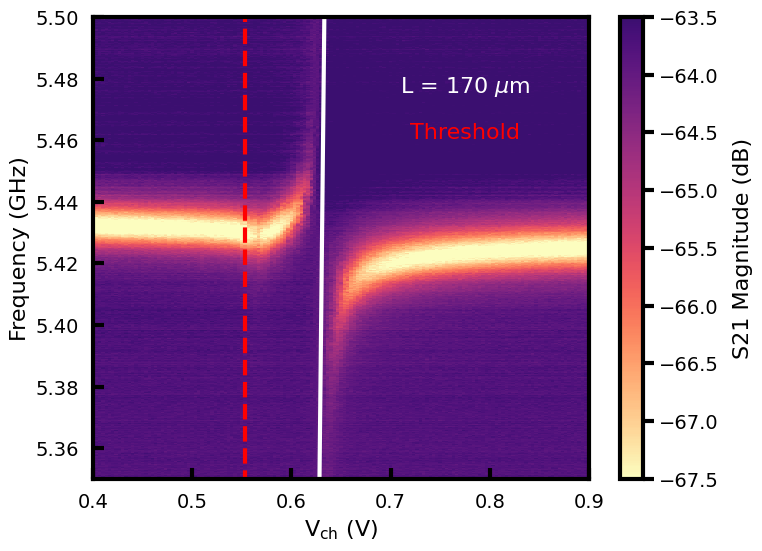

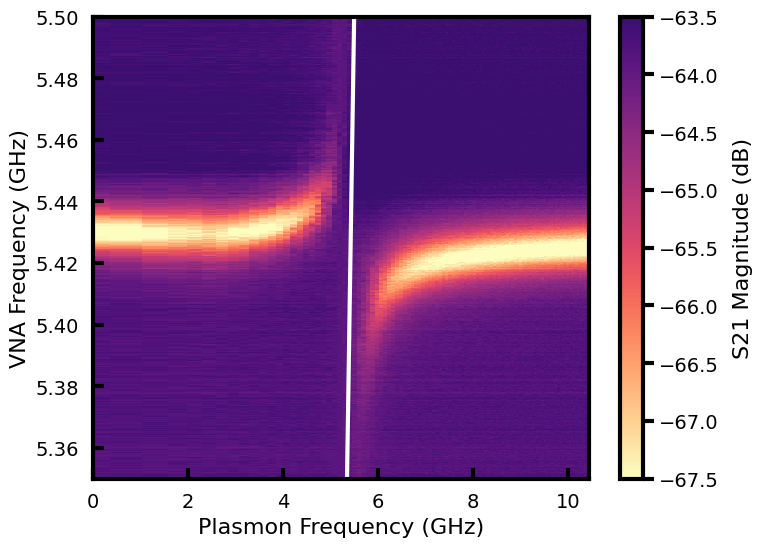

In [2]:
# Parameters and constants --------------------------------------------- #

# Import data via the load experiment function
filename = 'data/2026-02-09/2026-02-09_VNA-Vch_sweep-temp-B'
results = load_experiment_data(filename)

# Adjustment of the threshold voltage from the value in FEM
th_adj = -0.17

# Device parameters
L       = 170e-6      # Effective channel length [m]
N       = 1           # N mode
depth   = 1.17e-6     # Channel depth [m]
ch_wid  = 8e-6        # Channel width [m]

# Constants
m_e     = 9.1093e-31  # kg
eps0    = 8.854e-12   # F/m
e       = 1.602e-19   # C

# Peak selection parameters
f_marg  = 0.001e9     # Grace-period around f_r for vertical slice selection
frq_blk = 0.020e9     # Block around f_r for horizontal slice selection
sig_num = 1           # Number of st-dev for horizontal slice selection

# Plot formatting parameters
maxV    = -63.5
minV    = -67.5

font_t  = 14
font_l  = 16
line_w  = 3
line_l  = 8


# Data imports --------------------------------------------------------- #

# Extract the results
meta  = results["metadata"]
step  = results["step"]
sweep = results["sweep"]
data  = results["data"]

# Get the sweep header and type
sw_header = results["sweep_headers"]
sw_type = sw_header[0].lower() if sw_header else 'unknown'

# Saving figure
save_path = create_save_path(filename + '_AvdCrs', fig_type='jpg')

# Unpacking data
freq    = np.unique(data[:,-1])
vch     = step[:,0]
S21_re  = data[:,-3]
S21_im  = data[:,-2]
vna_lin = np.sqrt(S21_re**2 + S21_im**2)
vnamagn = 20*np.log10(np.sqrt(S21_re**2 + S21_im**2))
phas    = np.arctan2(S21_im, S21_re)
s21     = vnamagn.reshape(len(vch), len(freq))
v21     = vna_lin.reshape(len(vch), len(freq))
temper  = meta['T_MXC'][0]


# Remove VNA background from data -------------------------------------- #

# Find the vch of the plasmon peaks away from the avoided crossing
popt_top, pcov_top, func_top = fit_data(vch, s21[:,-1], 'lorz_inv')
popt_bot, pcov_bot, func_bot = fit_data(vch, s21[:, 0], 'lorz_inv')

# Find the middle most vch value for the avoided crossing
mid_vch = (popt_top[1] + popt_bot[1]) / 2
adj_vch = vch - mid_vch
arg_mid = np.argmin(np.abs(adj_vch))

back_s = []
back_v = []
for i in range(len(freq)):
    back_s.append(np.mean(s21[arg_mid-1:arg_mid+1,i]))
    back_v.append(np.mean(v21[arg_mid-1:arg_mid+1,i]))

background_s = back_s - np.mean(s21[arg_mid,:])
background_v = back_v - np.mean(v21[arg_mid,:])

s21 = s21 - background_s
v21 = v21 - background_v


# FEM imports ---------------------------------------------------------- #

params  = np.loadtxt(r'F:\Austin\Finite Element Modeling\CM-dev Density (2-26)\step-6_params.txt',
                     skiprows=1)

# Extract parameters
vch_fem = params[:,0]
width   = params[:,1]
ns_mean = params[:,2]
ns_max  = params[:,3]
nl_mean = params[:,4]
spacing = params[:,5]
nrows   = params[:,6]
C_ch    = params[:,7]
C_gt    = params[:,8]

# Adjust FEM channel bias to match experimental threshold voltage
vch_fem = vch_fem + th_adj

# Convert from FEM to experimental densities (mean) -------------------- #

ns_temp  = []
vch_temp = []

for i in range(len(ns_mean)):
    if ns_mean[i] <= 0:
        continue
    ns_temp.append(ns_mean[i])
    vch_temp.append(vch_fem[i])

popt, pcov, f_lin = fit_data(vch_temp, ns_temp, 'linear')

ns_exp = f_lin(vch, *popt)
for i in range(len(ns_exp)):
    if ns_exp[i] <= 0:
        ns_exp[i] = 0

# Convert from FEM to experimental effective widths -------------------- #

w_temp = []
v_temp = []

for i in range(len(width)):
    if width[i] > 0:
        w_temp.append(width[i])
        v_temp.append(vch_fem[i])


w_intrp = CubicSpline(v_temp, w_temp)
w_exp   = w_intrp(vch) * 1e-6   # [um] -> [m]  

for i in range(len(w_exp)):
    if w_exp[i] <= 0:
        w_exp[i] = 0

w_temp = np.array(w_temp)*1e-6
ns_temp = np.array(ns_temp)

# Convert from densities to plasmon frequencies ------------------------ #

# Wavevector
q_x = N * np.pi / L

# Screening parameter
gap   = ch_wid - w_exp         # gap between channel and gate in meters
F_qx = 0.5*(np.tanh(gap*q_x) + np.tanh(depth*q_x))

# Plasmon frequency 
omega_exp = 2*np.pi*np.sqrt((ns_exp*e**2)/(2*m_e*eps0)*np.sqrt(q_x**2*F_qx))
fp_exp = omega_exp / (2*np.pi)  # Convert to Hz for comparison with data

# Temporary model
gap_temp = ch_wid - w_temp
Fqx_temp = 0.5*(np.tanh(gap_temp*q_x) + np.tanh(depth*q_x))
omega_temp = 2*np.pi*np.sqrt((ns_temp*e**2)/(2*m_e*eps0)*
                             np.sqrt(q_x**2*Fqx_temp))
fp_temp = omega_temp / (2*np.pi)

# Plot threshold and plasmon frequency with vch x-axis ----------------- #

# Reduce colormap range
magma_segment = cm.get_cmap('magma_r')
magma_segment = mcolors.LinearSegmentedColormap.from_list(
    'magma_segment', magma_segment(np.linspace(0, 0.80, 256))
)

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot data
pcm = ax1.pcolormesh(vch, freq*1e-9, s21.T, shading='nearest', 
                     cmap=magma_segment, 
                     vmin=minV, vmax=maxV,
                     )
ax1.set_xlabel(r'V$_\mathrm{ch}$ (V)', fontsize=font_l, color='black')
ax1.set_ylabel('Frequency (GHz)', fontsize=font_l, color='black')
ax1.set_ylim(np.min(freq)*1e-9, np.max(freq)*1e-9)
ax1.set_xlim(np.min(vch), np.max(vch))
ax1.tick_params(axis='both', which='major', length=line_l, width=line_w, 
                labelsize=font_t, color='black', direction='in', pad=10)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax1)
cbar.ax.tick_params(axis='y', length=line_l, width=line_w, labelsize=font_t)
cbar.set_label('S21 Magnitude (dB)', fontsize=font_l, labelpad=10)
cbar.ax.yaxis.set_tick_params(width=line_w, length=line_l, direction='out', 
                              color='black')


# Find threshold voltage from data (this includes the adjustment from FEM)
for i in range(len(vch)):
    i += 1
    if ns_exp[i] > 0 and ns_exp[i-1] <= 0:
        vth = vch[i]
        break

# Plot the plasmon frequency line and threshold lines
ax1.plot(vch, fp_exp*1e-9, lw=3, label='Plasmon Frequency', color='white')
ax1.vlines(vth, 0, 5.50, lw=3, colors='red',
           linestyles='dashed', label='Threshold')

# Spines
for spine in ax1.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')

ax1.text(0.75,0.85, f'L = {L*1e6:.0f} $\mu$m', color='white', 
         fontsize=font_l, horizontalalignment='center', 
         verticalalignment='center', transform=ax1.transAxes)
ax1.text(0.75,0.75, r'Threshold', color='red', fontsize=font_l,
         horizontalalignment='center', verticalalignment='center',
         transform=ax1.transAxes)

plt.show()

# Frequency vs frequency plot ------------------------------------------ #

fig, ax1 = plt.subplots(figsize=(8, 6))

# Data
pcm = ax1.pcolormesh(fp_exp*1e-9, freq*1e-9, s21.T, shading='nearest', 
                     cmap=magma_segment, 
                     vmin=minV, vmax=maxV,
                     )

ax1.set_xlabel('Plasmon Frequency (GHz)', fontsize=font_l, color='black')
ax1.set_ylabel('VNA Frequency (GHz)', fontsize=font_l, color='black')
ax1.set_ylim(np.min(freq)*1e-9, np.max(freq)*1e-9)
ax1.set_xlim(0,fp_exp[-1]*1e-9)
ax1.tick_params(axis='both', which='major', length=line_l, width=line_w, 
                labelsize=font_t, color='black', direction='in', pad=10)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax1)
cbar.ax.tick_params(axis='y', length=line_l, width=line_w, labelsize=font_t)
cbar.set_label('S21 Magnitude (dB)', fontsize=font_l, labelpad=10)
cbar.ax.yaxis.set_tick_params(width=line_w, length=line_l, direction='out', 
                              color='black')

# Plot the plasmon frequency line
ax1.plot(fp_exp*1e-9, fp_exp*1e-9, lw=3, label='Plasmon Frequency', 
         color='white')

# Spines
for spine in ax1.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')

plt.show()

g-tilde = 1.04e+08 ± 9.48e+03 Hz


C:\Users\LHQS3\AppData\Local\Temp\ipykernel_4108\1647071461.py:228: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_segment = cm.get_cmap('magma_r');


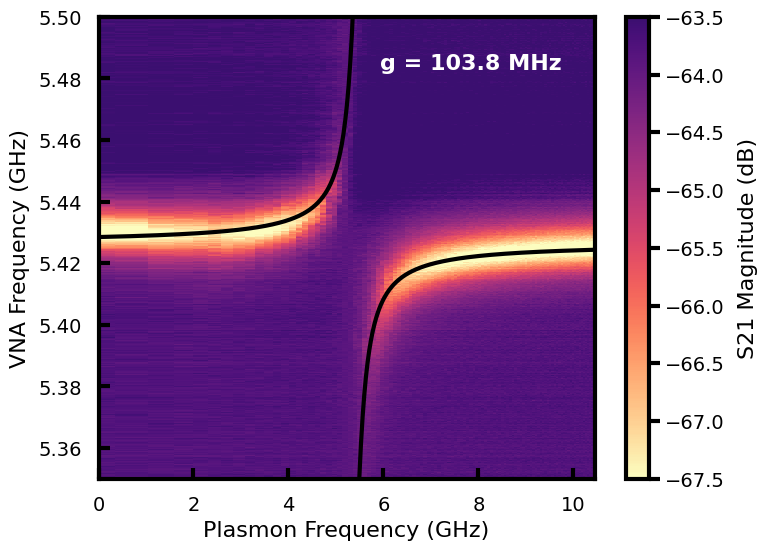

In [3]:
# Parameters ----------------------------------------------------------- #

# Peak selection parameters
frq_blk = 20e6        # Block around f_r for horizontal slice selection
sig_num = 1           # Number of st-dev for horizontal slice selection


# Resonator fitting away from hybridization ---------------------------- #

# Average of lowest and highest bias resonances
l_opt, l_cov, l_ilorz = fit_data(freq, v21[ 0,:], 'lorz_inv')
h_opt, h_cov, h_ilorz = fit_data(freq, v21[-1,:], 'lorz_inv')
f_r = (l_opt[1] + h_opt[1]) / 2


# Linear fit of Plasmon frequency -------------------------------------- #

# Linear fit the points of f_p closest to f_r 
# Note: Use f here since the data is in Hz, not rad/s
indx = np.argmin(np.abs(fp_exp - f_r))
opt, cov, linappx = fit_data(fp_exp[(indx-2):(indx+2)], 
                             fp_exp[(indx-2):(indx+2)], 
                             'linear')

# Function that models both branches (+,-) simultaneously (in Hz)
def avoided_crossing_real(v_concat, g, f_r):
    v = v_concat[0, :]
    s = v_concat[1, :]
    f_p = linappx(v, *opt)
    delta = 0.5 * (f_r - f_p)
    return 0.5*(f_r + f_p) + s*np.sqrt(delta**2 + g**2)


# Extract peaks in both axes ------------------------------------------- #

# Fit peaks along both axes 
peaks    = []
horz     = []
peak_wid = [] # FWHM of linear data
horz_wid = [] # FWHM of horizontal slices

for j in range(len(vch)):
    popt, pcov, func = fit_data(freq, s21[j,:], 'lorz_inv')
    peaks.append(popt[1])
    # _l -> linear (v21 is in Watts)
    popt_l, pcov_l, func_l = fit_data(freq, v21[j,:],'lorz_inv')
    peak_wid.append(popt_l)

for k in range(len(freq)):
    popt, pcov, func = fit_data(fp_exp, s21[:,k], 'lorz_inv')
    horz.append(popt[1])
    # _h -> horizontal (v21 is in Watts)
    popt_h, pcov_h, func_h = fit_data(fp_exp, v21[:,k],'lorz_inv')
    horz_wid.append(popt_h)

peak_wid = np.array(peak_wid)
horz_wid = np.array(horz_wid)


# Vertical slice peaks ------------------------------------------------- #

xpV   = []
ypV   = []
pVwid = []

xmV   = []
ymV   = []
mVwid = []

for i in range(len(peaks)):
    if peaks[i] > f_r \
    and peaks[i] < np.max(freq) \
    and i < np.argmin(peaks):
        xpV.append(fp_exp[i])
        ypV.append(peaks[i])
        pVwid.append(peak_wid[i,2])

for i in range(len(peaks)):
    if peaks[i] > np.min(freq) \
    and peaks[i] < f_r \
    and i > np.argmin(peaks):
        xmV.append(fp_exp[i])
        ymV.append(peaks[i])
        mVwid.append(peak_wid[i,2])


# Horizontal slice peaks ----------------------------------------------- #

xpH   = []
ypH   = []
pHwid = []

xmH   = []
ymH   = []
mHwid = []

xpH_temp   = []
ypH_temp   = []
pHwid_temp = []

for i in range(len(freq)):
    if freq[i] > f_r + frq_blk:
        xpH_temp.append(horz[i])
        ypH_temp.append(freq[i])
        pHwid_temp.append(horz_wid[i,2])


xpH_mu  = np.mean(xpH_temp)
xpH_sig = np.std(xpH_temp)

for i in range(len(xpH_temp)):
    if xpH_temp[i] > xpH_mu - sig_num*xpH_sig \
    and xpH_temp[i] < xpH_mu + sig_num*xpH_sig:
        xpH.append(xpH_temp[i])
        ypH.append(ypH_temp[i])
        pHwid.append(pHwid_temp[i])

xmH_temp   = []
ymH_temp   = []
mHwid_temp = []

for i in range(len(freq)):
    if freq[i] < f_r - frq_blk:
        xmH_temp.append(horz[i])
        ymH_temp.append(freq[i])
        mHwid_temp.append(horz_wid[i,2])

xmH_mu  = np.mean(xmH_temp)
xmH_sig = np.std(xmH_temp)

for i in range(len(xmH_temp)):
    if xmH_temp[i] > xmH_mu - sig_num*xmH_sig \
    and xmH_temp[i] < xmH_mu + sig_num*xmH_sig:
        xmH.append(xmH_temp[i])
        ymH.append(ymH_temp[i])
        mHwid.append(mHwid_temp[i])

# Remove middle 10 points of vertical peaks
xpV   = xpV[:-5]
ypV   = ypV[:-5]
pVwid = pVwid[:-5]
xmV   = xmV[5:]
ymV   = ymV[5:]
mVwid = mVwid[5:]

# Cut xpV = 0 points
for i in range(len(xpV)):
    if xpV[i] == 0.0 and xpV[i+1] > 0.0:
        xpV = xpV[i:]
        ypV = ypV[i:]
        pVwid = pVwid[i:]
        break


# Sort horizontal peaks by arguments ----------------------------------- #

# Sort the horizontal slices?  Vertical slices are already sorted.
sort = True

if sort:

    # Plus horizontal branch
    idx1  = np.argsort(xpH)
    xpH   = np.array(xpH)[idx1]
    ypH   = np.array(ypH)[idx1]
    pHwid = np.array(pHwid)[idx1]

    # Minus horizontal branch
    idx2  = np.argsort(xmH)
    xmH   = np.array(xmH)[idx2]
    ymH   = np.array(ymH)[idx2]
    mHwid = np.array(mHwid)[idx2]


# Fit to the simple avoided crossing to get g-tilde -------------------- #

# Concatenate in a known order:  V+, V-, H+, H-
x_all   = np.concatenate([  xpV,   xmV,   xpH,   xmH])
y_all   = np.concatenate([  ypV,   ymV,   ypH,   ymH])
all_wid = np.concatenate([pVwid, mVwid, pHwid, mHwid])

# Sign array to indicate branch: +1 for plus, -1 for minus
s_all = np.concatenate([
    np.ones_like(xpV),  -np.ones_like(xmV),
    np.ones_like(xpH),  -np.ones_like(xmH)
])

# Stack v and s for curve_fit (2xN array)
v_concat = np.vstack([x_all, s_all])

# Weights / sigmas
sigma_Vp = np.full_like(ypV, 1.0e4)
sigma_Vm = np.full_like(ymV, 1.0e4)
sigma_Hp = np.full_like(ypH, 3.0e6)
sigma_Hm = np.full_like(ymH, 3.0e6)

sigma_all = np.concatenate([sigma_Vp, sigma_Vm, sigma_Hp, sigma_Hm])

# Initial guesses: g ~ 10 MHz, f_r = f_r
p0     = [8e7, f_r]
bounds = ([1e5, f_r - 1e8], [1e9, f_r + 1e8])

# Fit the model to the data
opt_all, cov_all = curve_fit(
    avoided_crossing_real,
    v_concat, y_all,
    p0=p0, bounds=bounds,
    sigma=sigma_all,
    # return covariance in absolute units
    absolute_sigma=True,   
    maxfev=20000)

# Fit outputs 
g_tilde, f_r_fit = opt_all
g_err = np.sqrt(cov_all[0,0])

print('g-tilde = {:.2e} ± {:.2e} Hz'.format(g_tilde, g_err))


# Plot data, peaks, and fit results ------------------------------------ #

# Create a dense set of v values for plotting the fit
vfit = np.linspace(x_all.min(), x_all.max(), 600)
vfit_plus  = np.vstack([vfit,  np.ones_like(vfit)])
vfit_minus = np.vstack([vfit, -np.ones_like(vfit)])

# Color map for the 2D plot
color_segment = cm.get_cmap('magma_r');
color_segment = mcolors.LinearSegmentedColormap.from_list(
    'magma_segment', color_segment(np.linspace(0, 0.80, 256)));

fig, ax_plot = plt.subplots(figsize=(8,6))

# Plot: 2D data
pcm = ax_plot.pcolormesh(fp_exp*1e-9, freq*1e-9, s21.T, shading='nearest',
                        cmap=color_segment, vmax=maxV, vmin=minV)

# Plot: peaks
'''
ax_plot.plot(np.array(xpV)*1e-9, np.array(ypV)*1e-9,
              '.', alpha=0.6, markersize=6, 
             label='+V', color='green')
ax_plot.plot(np.array(xmV)*1e-9, np.array(ymV)*1e-9,
              '.', alpha=0.6, markersize=6, 
             label='-V', color='blue')
ax_plot.plot(np.array(xpH)*1e-9, np.array(ypH)*1e-9,
              '.', alpha=0.3, markersize=6, 
             label='+H', color='lightgreen')
ax_plot.plot(np.array(xmH)*1e-9, np.array(ymH)*1e-9,
              '.', alpha=0.3, markersize=6, 
             label='-H', color='skyblue')
'''

# Plot: fit
ax_plot.plot(vfit*1e-9, avoided_crossing_real(vfit_plus,  *opt_all)*1e-9, 
            '-', lw=3, label='fit (plus)', color='black')
ax_plot.plot(vfit*1e-9, avoided_crossing_real(vfit_minus, *opt_all)*1e-9, 
            '-', lw=3, label='fit (minus)', color='black')

ax_plot.text(0.75, 0.90, f"g = {g_tilde/1e6:.1f} MHz", 
             fontsize=16, transform=ax_plot.transAxes, 
             verticalalignment='center', color='white',
             horizontalalignment='center',
             fontweight='bold')

# Axis labels
ax_plot.set_xlabel('Plasmon Frequency (GHz)', fontsize=font_l)
ax_plot.set_ylabel('VNA Frequency (GHz)', color='black',
              fontsize=font_l, labelpad=6)

# Style plot parameters
ax_plot.tick_params(axis='both', length=line_l, width=line_w, 
                    labelsize=font_t,
               direction='in', pad=12, colors='black')
ax_plot.set_ylim(np.min(freq)*1e-9, np.max(freq)*1e-9)
ax_plot.set_xlim(np.min(fp_exp)*1e-9, np.max(fp_exp)*1e-9)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax_plot)
cbar.ax.tick_params(axis='y', length=line_l, width=line_w, 
                    labelsize=font_t)
cbar.set_label('S21 Magnitude (dB)', fontsize=font_l, labelpad=10)
cbar.ax.yaxis.set_tick_params(width=line_w, length=line_l, 
                                   direction='out', 
                                   color='black')

# Spines
for spine in ax_plot.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')

C:\Users\LHQS3\AppData\Local\Temp\ipykernel_4108\809299968.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_segment = cm.get_cmap('magma_r');


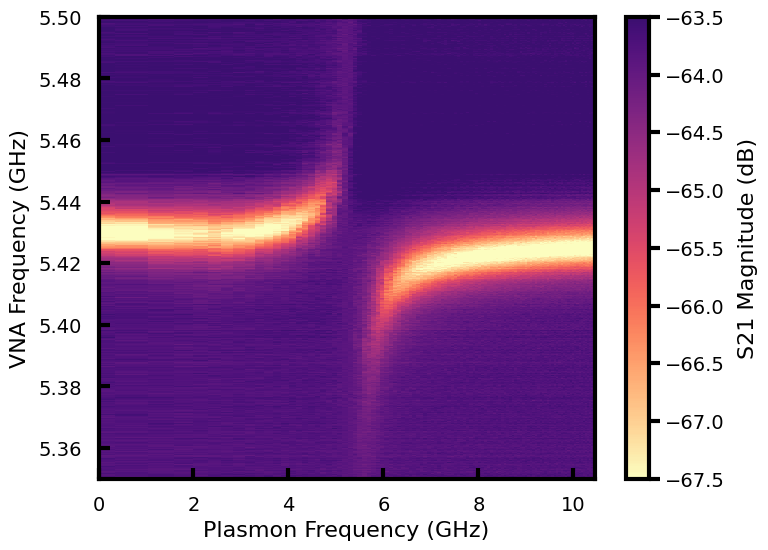

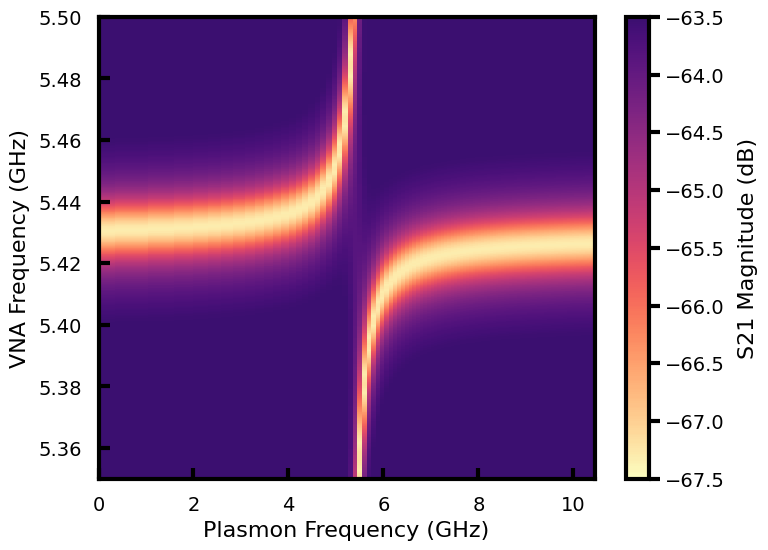

In [17]:
# Base parameters 
ampl   = 4.2
offset = -67.3

# Fit parameter adjustments
g_adj = 1
k_adj = 0.8
H_adj = 1/10

# Fit plot range adjustments
fit_min = minV
fit_max = maxV


# Complex equation to get S21 map -------------------------------------- #

# Averages of FWHM away from avoided crossing
kappa = (l_opt[2] + h_opt[2]) / 2

# Average horizontal FWHM (for later gamma guess)
mean_Hwid = (np.mean(pHwid) + np.mean(mHwid))/2

# Complex model for S21 mapping
def S21_model(f_pla, f_vna, f_r, g, kap, gam, A_p=1.0, A_m=1.0,
              abs = True):

    # angular frequencies (rad/s)
    w_vna = 2*np.pi * f_vna[:, None]  # (Nv, 1)
    w_pla = 2*np.pi * f_pla[None, :]  # (1, Np)
    w_r   = 2*np.pi * f_r
    g_w   = 2*np.pi * g
    kap_w = 2*np.pi * kap
    gam_w = 2*np.pi * gam

    # complex hybrid frequencies (CM eq 4.15)
    delta   = 0.5 * ((w_r - 1j*kap_w) - (w_pla - 1j*gam_w))
    omega_c = 0.5 * ((w_r - 1j*kap_w) + (w_pla - 1j*gam_w))
    root    = np.lib.scimath.sqrt(delta**2 + g_w**2)
    omega_p = omega_c + root
    omega_m = omega_c - root

    # widths (positive)
    Gam_p = np.abs(omega_p.imag)
    Gam_m = np.abs(omega_m.imag)

    # Proper, dimensionless Lorentzians
    Rp = (Gam_p**2) / ((w_vna - omega_p.real)**2 + Gam_p**2)
    Rm = (Gam_m**2) / ((w_vna - omega_m.real)**2 + Gam_m**2)

    # both modes produce dips (CM eq 4.18)
    S21 = 1.0 - A_p*Rp - A_m*Rm

    if abs:
        S21 = np.abs(S21)

    return S21*ampl + offset


# Fitting function and scaling factors --------------------------------- #

S21_fit = S21_model(fp_exp, freq, f_r, 
                    g_tilde*g_adj, 
                    kappa*k_adj, 
                    mean_Hwid*H_adj)


# Plot data, peaks, and fit results ------------------------------------ #

# Create a dense set of v values for plotting the fit
vfit = np.linspace(x_all.min(), x_all.max(), 600)
vfit_plus  = np.vstack([vfit,  np.ones_like(vfit)])
vfit_minus = np.vstack([vfit, -np.ones_like(vfit)])

# Color map for the 2D plot
color_segment = cm.get_cmap('magma_r');
color_segment = mcolors.LinearSegmentedColormap.from_list(
    'magma_segment', color_segment(np.linspace(0, 0.80, 256)));

fig, ax_plot = plt.subplots(figsize=(8,6))

# Plot: 2D data
pcm = ax_plot.pcolormesh(fp_exp*1e-9, freq*1e-9, s21.T, shading='nearest',
                        cmap=color_segment, vmax=maxV, vmin=minV)

# Plot: fit
'''
ax_plot.plot(vfit*1e-9, avoided_crossing_real(vfit_plus,  *opt_all)*1e-9, 
            '-', lw=3, label='fit (plus)', color='white')
ax_plot.plot(vfit*1e-9, avoided_crossing_real(vfit_minus, *opt_all)*1e-9, 
            '-', lw=3, label='fit (minus)', color='white')
'''

# Axis labels
ax_plot.set_xlabel('Plasmon Frequency (GHz)', fontsize=font_l)
ax_plot.set_ylabel('VNA Frequency (GHz)', color='black',
              fontsize=font_l, labelpad=6)

# Style plot parameters
ax_plot.tick_params(axis='both', length=line_l, width=line_w, 
                    labelsize=font_t,
               direction='in', pad=12, colors='black')
ax_plot.set_ylim(np.min(freq)*1e-9, np.max(freq)*1e-9)
ax_plot.set_xlim(np.min(fp_exp)*1e-9, np.max(fp_exp)*1e-9)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax_plot)
cbar.ax.tick_params(axis='y', length=line_l, width=line_w, 
                    labelsize=font_t)
cbar.set_label('S21 Magnitude (dB)', fontsize=font_l, labelpad=10)
cbar.ax.yaxis.set_tick_params(width=line_w, length=line_l, 
                                   direction='out', 
                                   color='black')

# Spines
for spine in ax_plot.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')
plt.show()


# Plot data, peaks, and fit results ------------------------------------ #

fig, ax_plot = plt.subplots(figsize=(8,6))

# Plot: 2D data
pcm = ax_plot.pcolormesh(fp_exp*1e-9, freq*1e-9, 
                        S21_fit,
                        shading='nearest',
                        cmap=color_segment,
                        vmax=fit_max, vmin=fit_min, 
                        )

# Plot: fit
'''
ax_plot.plot(vfit*1e-9, avoided_crossing_real(vfit_plus,  *opt_all)*1e-9, 
            '-', lw=3, label='fit (plus)', color='white')
ax_plot.plot(vfit*1e-9, avoided_crossing_real(vfit_minus, *opt_all)*1e-9, 
            '-', lw=3, label='fit (minus)', color='white')
'''

# Axis labels
ax_plot.set_xlabel('Plasmon Frequency (GHz)', fontsize=font_l)
ax_plot.set_ylabel('VNA Frequency (GHz)', color='black',
              fontsize=font_l, labelpad=6)

# Style plot parameters
ax_plot.tick_params(axis='both', length=line_l, width=line_w, 
                    labelsize=font_t,
               direction='in', pad=12, colors='black')
ax_plot.set_ylim(np.min(freq)*1e-9, np.max(freq)*1e-9)
ax_plot.set_xlim(np.min(fp_exp)*1e-9, np.max(fp_exp)*1e-9)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax_plot)
cbar.ax.tick_params(axis='y', length=line_l, width=line_w, 
                    labelsize=font_t)
cbar.set_label('S21 Magnitude (dB)', fontsize=font_l, labelpad=10)
cbar.ax.yaxis.set_tick_params(width=line_w, length=line_l, 
                                   direction='out', 
                                   color='black')

# Spines
for spine in ax_plot.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')

## **Fitting 2D via LMFIT**

In [ ]:
# Fit parameter adjustments
g_adj = 1
k_adj = 0.8
H_adj = 1/10


# Definition for LMFIT fitting ----------------------------------------- #

# When using LMFIT, the fitting function needs to included all parameters
# that we want to be able to adjust.  Since I am trying to align the 2D 
# avoided crossing data with the S21 model, I will also need to include 
# the amplitude and offset parameters.  The only thing not included in 
# the definition is the 2D data matrix.

# Kappa in this equation ends up being the HWHM not the FWHM.  

def S21_model_lm(f_pla, f_vna, f_r, g, kap, gam, A_p, A_m, ampl, offset):

    # angular frequencies (rad/s)
    w_vna = 2*np.pi * f_vna[:, None]  # (Nv, 1)
    w_pla = 2*np.pi * f_pla[None, :]  # (1, Np)
    w_r   = 2*np.pi * f_r
    g_w   = 2*np.pi * g
    kap_w = 2*np.pi * kap
    gam_w = 2*np.pi * gam

    # complex hybrid frequencies (CM eq 4.15)
    delta   = 0.5 * ((w_r - 1j*kap_w) - (w_pla - 1j*gam_w))
    omega_c = 0.5 * ((w_r - 1j*kap_w) + (w_pla - 1j*gam_w))
    root    = np.lib.scimath.sqrt(delta**2 + g_w**2)
    omega_p = omega_c + root
    omega_m = omega_c - root

    # widths (positive)
    Gam_p = np.abs(omega_p.imag)
    Gam_m = np.abs(omega_m.imag)

    # Proper, dimensionless Lorentzians
    Rp = (Gam_p**2) / ((w_vna - omega_p.real)**2 + Gam_p**2)
    Rm = (Gam_m**2) / ((w_vna - omega_m.real)**2 + Gam_m**2)

    # both modes produce dips (CM eq 4.18)
    S21 = ampl*np.abs(1.0 - A_p*Rp - A_m*Rm) + offset
    return S21


# Defining LMFIT parameters -------------------------------------------- #

# set all parameters except for the independent variablse of the sweep.
# In the case of this code, I am omitting the two frequency inputs as 
# these are the independent variables that define the 2D sweep.  Vary is
# used in the parameter definitions to fix or allow variations of that 
# parameter in the fit.  Value offers either the fixed variable value or
# the initial guess for a variable parameter.

# Setup model
lmodel = lm.Model(S21_model_lm, independent_vars=['f_pla', 'f_vna'])
params = lmodel.make_params()

# Define parameters
params['f_r'].set(             value=f_r, vary= True)
params['g'].set(     value=g_tilde*g_adj, vary= True)
params['kap'].set(     value=kappa*k_adj, vary= True)
params['gam'].set(value=mean_Hwid*H_adj,
                  min=1e6,
                  max=1e10, 
                  vary= True)
params['A_p'].set(             value=1.0, vary=False)
params['A_m'].set(             value=1.0, vary=False)
params['ampl'].set(           value=ampl, vary= True)
params['offset'].set(       value=offset, vary= True)


# Perform LMFIT fitting ------------------------------------------------ #

fit_result = lmodel.fit(s21.T, params, f_pla=fp_exp, f_vna=freq)

# Print fit report
print(fit_result.fit_report())

[[Model]]
    Model(S21_model_lm)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 234
    # data points      = 151151
    # variables        = 6
    chi-square         = 16524.4821
    reduced chi-square = 0.10932867
    Akaike info crit   = -334551.109
    Bayesian info crit = -334491.553
    R-squared          = 0.87711860
[[Variables]]
    f_r:     5.4278e+09 +/- 7784.73656 (0.00%) (init = 5.428541e+09)
    g:       1.1093e+08 +/- 39442.3925 (0.04%) (init = 1.038298e+08)
    kap:     6510018.57 +/- 12754.7208 (0.20%) (init = 9831148)
    gam:     1000000.22 +/- 497100.025 (49.71%) (init = 5.345165e+07)
    A_p:     1 (fixed)
    A_m:     1 (fixed)
    ampl:    3.91782149 +/- 0.00466454 (0.12%) (init = 4.2)
    offset: -67.4583145 +/- 0.00474047 (0.01%) (init = -67.3)
[[Correlations]] (unreported correlations are < 0.100)
    C(ampl, offset) = -0.9717
    C(kap, offset)  = +0.6876
    C(kap, ampl)    = -0.5815
    C(g, gam)       = -0.1527
    C(kap, gam)

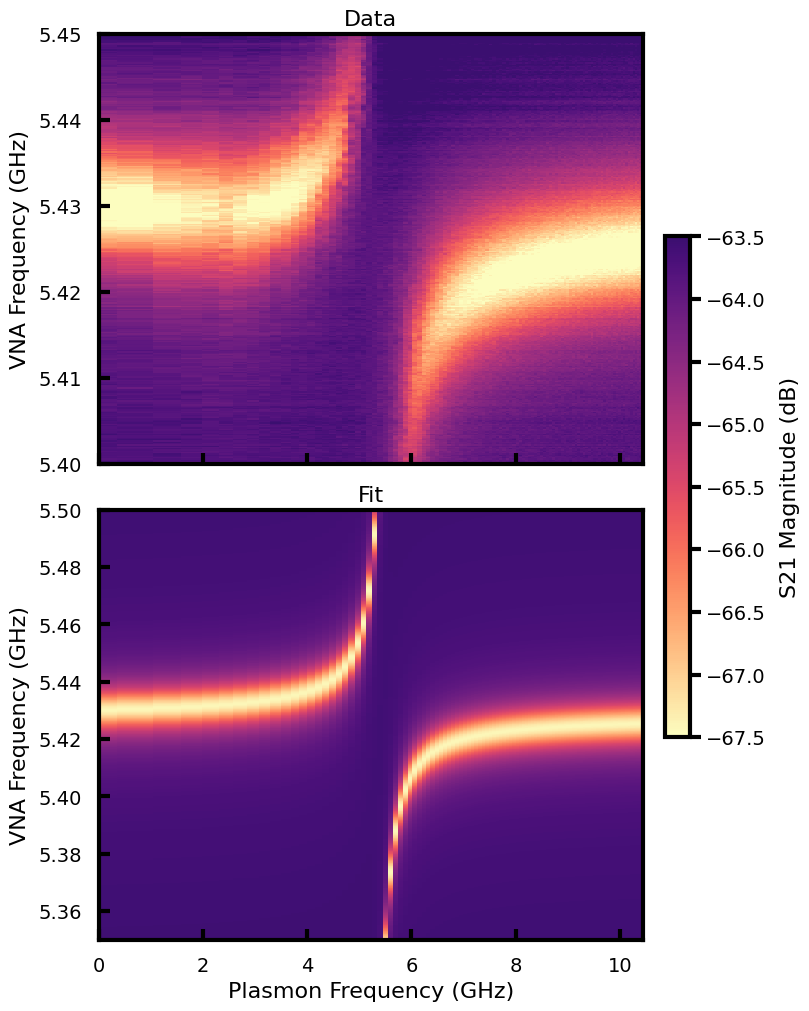

In [41]:
# Setup a two panel figure --------------------------------------------- #

# A shared normalization for the colorbar
norm = Normalize(vmin=minV, vmax=maxV)

# Set up the two-panel figure (shared x-axis)
fig, axes = plt.subplots(
    nrows=2, ncols=1, 
    figsize=(8, 10), 
    sharex=True, 
    constrained_layout=True
)

# Name the axes
ax_top, ax_bottom = axes


# Plot data (top panel) ------------------------------------------------ #

pcm_top = ax_top.pcolormesh(
    fp_exp*1e-9,
    freq*1e-9,
    s21.T,
    shading='nearest',
    cmap=color_segment,
    norm=norm
)


# Plot LMFIT (bottom panel) -------------------------------------------- #

pcm_bottom = ax_bottom.pcolormesh(
    fp_exp*1e-9,
    freq*1e-9,
    fit_result.best_fit,
    shading='nearest',
    cmap=color_segment,
    norm=norm
)


# Plotting parameters -------------------------------------------------- #

# Shared x-axis label
ax_bottom.set_xlabel('Plasmon Frequency (GHz)', fontsize=font_l)

# Separate y-axis labels
ax_top.set_ylabel('VNA Frequency (GHz)', color='black', 
                  fontsize=font_l, labelpad=6)
ax_bottom.set_ylabel('VNA Frequency (GHz)', color='black', 
                     fontsize=font_l, labelpad=6)

# Set consistent limits
for ax in axes:
    ax.set_xlim(np.min(fp_exp)*1e-9, np.max(fp_exp)*1e-9)
    ax.set_ylim(np.min(freq)*1e-9,   np.max(freq)*1e-9)

# Optional panel titles
ax_top.set_title('Data', fontsize=font_l)
ax_bottom.set_title('Fit', fontsize=font_l)

# Tick and spine styling
for ax in axes:
    ax.tick_params(axis='both', length=line_l, width=line_w,
                   labelsize=font_t, direction='in', pad=12, colors='black')
    # Spines
    for spine in ax.spines.values():
        spine.set_linewidth(line_w)
        spine.set_color('black')

ax_top.set_ylim(5.40,5.45)

# Shared colorbar for both panels
cbar = fig.colorbar(
    pcm_top,
    ax=axes,            # attach to both axes
    location='right',
    fraction=0.046,     # size of the colorbar relative to the axes
    pad=0.04            # space between rightmost axes and colorbar
)

# Colorbar styling
cbar.set_label('S21 Magnitude (dB)', fontsize=font_l, labelpad=10)
cbar.ax.tick_params(axis='y', length=line_l, 
                    width=line_w, labelsize=font_t)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')


## **Windowed LMFIT**

In [73]:
# Window
freq_wind = freq[333:667]
fp_wind   = fp_exp
s21_wind  = s21[:,333:667].T
v21_wind  = v21[:,333:667].T


# Perform LMFIT fitting ------------------------------------------------ #

fit_window = lmodel.fit(v21_wind, params,
                          f_pla=fp_wind, f_vna=freq_wind)

# Print fit report
print(fit_window.fit_report())

[[Model]]
    Model(S21_model_lm)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 71
    # data points      = 50434
    # variables        = 6
    chi-square         = 2.6419e-05
    reduced chi-square = 5.2389e-10
    Akaike info crit   = -1077755.51
    Bayesian info crit = -1077702.54
    R-squared          = 0.92111417
[[Variables]]
    f_r:     5.4278e+09 +/- 9275.97534 (0.00%) (init = 5.428541e+09)
    g:       1.1317e+08 +/- 88265.5952 (0.08%) (init = 1.038298e+08)
    kap:     7853878.02 +/- 21749.7041 (0.28%) (init = 9831148)
    gam:     52145962.2 +/- 505901.977 (0.97%) (init = 5.345165e+07)
    A_p:     1 (fixed)
    A_m:     1 (fixed)
    ampl:    2.6444e-04 +/- 3.4879e-07 (0.13%) (init = 4.2)
    offset:  4.1575e-04 +/- 3.1868e-07 (0.08%) (init = -67.3)
[[Correlations]] (unreported correlations are < 0.100)
    C(kap, offset)  = +0.6698
    C(ampl, offset) = -0.6471
    C(g, gam)       = +0.3067
    C(kap, gam)     = +0.2548
    C(f_r, g)     

Figure saved to: data/2026-02-09\2026-02-09_VNA-Vch_sweep-temp-B_windowed_fit_Fig_1.jpg


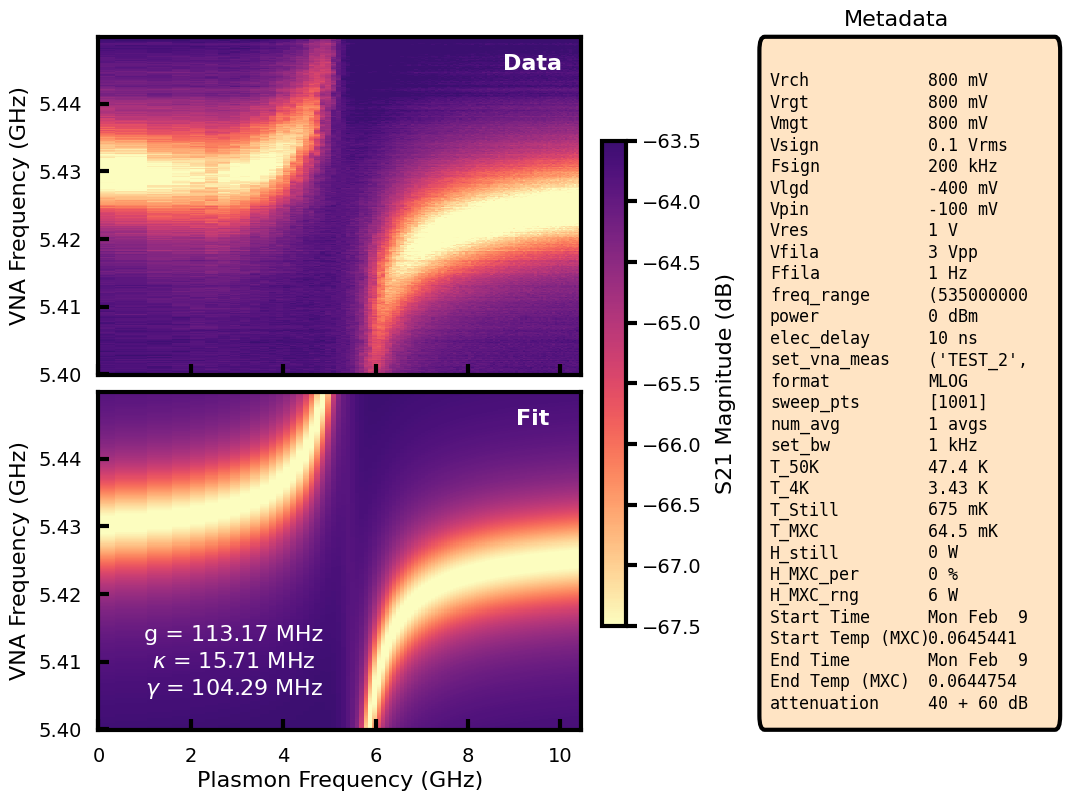

In [ ]:
# Setup a two panel figure --------------------------------------------- #

# A shared normalization for the colorbar
norm = Normalize(vmin=minV, vmax=maxV)
#norm = Normalize(vmin=fit_window.best_fit.min(), vmax=fit_window.best_fit.max())

# Set up the two-panel plot (shared x-axis)
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[1.0, 0.5],
    height_ratios=[1.0, 1.0],
    hspace=0.05, wspace=0.35
)

# Define axes
ax_top    = fig.add_subplot(gs[0, 0])
ax_bottom = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_meta   = fig.add_subplot(gs[:, 1])

# Package data axes for shared styling
axes = [ax_top, ax_bottom]


# Metadata table ------------------------------------------------------- #

ax_meta.set_axis_off()
# Call your existing metadata table drawer on this axis
meta_table(ax_meta, meta, comm_on=True, facecolor='bisque')


# Plot data (top panel) ------------------------------------------------ #

pcm_top = ax_top.pcolormesh(
    fp_wind*1e-9,
    freq_wind*1e-9,
    20*np.log10(np.abs(v21_wind)),
    shading='nearest',
    cmap=color_segment,
    norm=norm
)


# Plot LMFIT (bottom panel) -------------------------------------------- #

pcm_bottom = ax_bottom.pcolormesh(
    fp_wind*1e-9,
    freq_wind*1e-9,
    20*np.log10(np.abs(fit_window.best_fit)),
    shading='nearest',
    cmap=color_segment,
    norm=norm
)


# Plotting parameters -------------------------------------------------- #

# Shared x-axis label
ax_bottom.set_xlabel('Plasmon Frequency (GHz)', fontsize=font_l)

# Separate y-axis labels
ax_top.set_ylabel('VNA Frequency (GHz)', color='black', 
                  fontsize=font_l, labelpad=6)
ax_bottom.set_ylabel('VNA Frequency (GHz)', color='black', 
                     fontsize=font_l, labelpad=6)

# Set consistent limits
for ax in axes:
    ax.set_xlim(np.min(fp_wind)*1e-9, np.max(fp_wind)*1e-9)
    ax.set_ylim(np.min(freq_wind)*1e-9,   np.max(freq_wind)*1e-9)

# Optional panel titles
ax_top.text(0.90, 0.92, 'Data', fontsize=font_l, color='white',
             horizontalalignment='center', verticalalignment='center',
             transform=ax_top.transAxes, fontweight='bold')
ax_bottom.text(0.90, 0.92, 'Fit', fontsize=font_l, color='white',
             horizontalalignment='center', verticalalignment='center',
             transform=ax_bottom.transAxes, fontweight='bold')

# Fit values

# coupling strength g
ax_bottom.text(0.28, 0.28, 
             f"g = {fit_window.params['g'].value/1e6:.2f} MHz",
             fontsize=font_l, color='white', # fontweight='bold',
             horizontalalignment='center', verticalalignment='center',
             transform=ax_bottom.transAxes)

# resonator linewidth kappa (converted from HWHM to FWHM and to MHz)
ax_bottom.text(0.28, 0.20,
             f"$\\kappa$ = {fit_window.params['kap'].value*2/1e6:.2f} MHz",
             fontsize=font_l, color='white', # fontweight='bold',
             horizontalalignment='center', verticalalignment='center',
             transform=ax_bottom.transAxes)

# plasmon linewidth gamma (converted from HWHM to FWHM and to MHz)
ax_bottom.text(0.28, 0.12,
             f"$\\gamma$ = {fit_window.params['gam'].value*2/1e6:.2f} MHz",
             fontsize=font_l, color='white', # fontweight='bold',
             horizontalalignment='center', verticalalignment='center',
             transform=ax_bottom.transAxes)


# Tick and spine styling
for ax in axes:
    ax.tick_params(axis='both', length=line_l, width=line_w,
                   labelsize=font_t, direction='in', pad=12, colors='black')
    # Spines
    for spine in ax.spines.values():
        spine.set_linewidth(line_w)
        spine.set_color('black')
# Remove top x-axis tick labels
ax_top.tick_params(labelbottom=False)

# Shared colorbar for both panels
cbar = fig.colorbar(
    pcm_top,
    ax=axes,            # attach to both axes
    location='right',
    fraction=0.046,     # size of the colorbar relative to the axes
    pad=0.04            # space between rightmost axes and colorbar
)

# Colorbar styling
cbar.set_label('S21 Magnitude (dB)', fontsize=font_l, labelpad=10)
cbar.ax.tick_params(axis='y', length=line_l, 
                    width=line_w, labelsize=font_t)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(line_w)
    spine.set_color('black')


# Saving figure
save_path = create_save_path(filename + '_windowed_fit', fig_type='jpg')
#fig.savefig(save_path, dpi=400, bbox_inches='tight')
print(f"Figure saved to: {save_path}")

### **Checking if kappa and gamma are HWHM or FWHM**

15.191011679641349


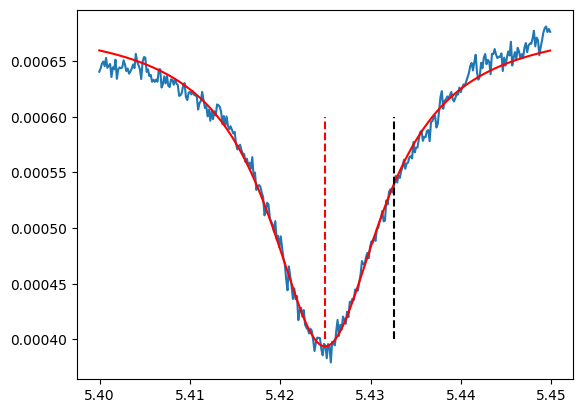

In [82]:
plt.plot(freq_wind*1e-9, v21_wind[:,-1])
test_opt, test_cov, test_func = fit_data(freq_wind, v21_wind[:,-1], 'lorz_inv')
plt.plot(freq_wind*1e-9, test_func(freq_wind, *test_opt), 'r-')

plt.vlines(test_opt[1]*1e-9, 4e-4, 6e-4, 'r', ls='--')
plt.vlines(test_opt[1]*1e-9 + test_opt[2]*1e-9/2, 4e-4, 6e-4, 'k', ls='--')

print(test_opt[2]*1e-6)

15.752912491097444
15.707756036374661


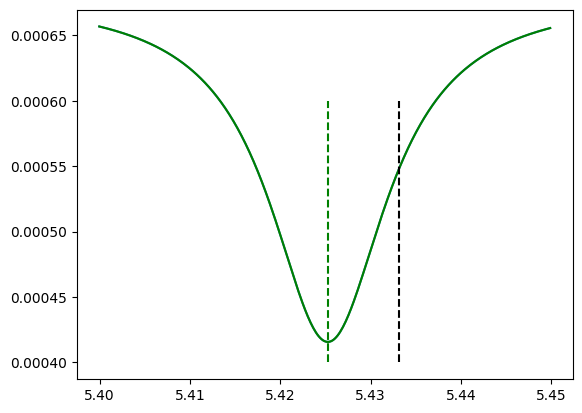

In [91]:
plt.plot(freq_wind*1e-9, fit_window.best_fit[:,-1])
test_opt2, test_cov2, test_func2 = fit_data(freq_wind, fit_window.best_fit[:,-1], 'lorz_inv')
plt.plot(freq_wind*1e-9, test_func2(freq_wind, *test_opt2), 'g-')
plt.vlines(test_opt2[1]*1e-9, 4e-4, 6e-4, 'g', ls='--')
plt.vlines(test_opt2[1]*1e-9 + test_opt2[2]*1e-9/2, 4e-4, 6e-4, 'k', ls='--')
print(test_opt2[2]*1e-6)
print(fit_window.params['kap'].value/1e6 * 2)